In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")
print("imports done")

imports done


In [11]:
TICKER = "RELIANCE.NS"
START_DATE = "2020-01-01"
END_DATE = "2024-12-31"

np.random.seed(42)
dates = pd.date_range(start=START_DATE, end=END_DATE, freq="B")
n = len(dates)

returns_sim = np.random.normal(loc=0.0005, scale=0.018, size=n)
close = 2200 * np.exp(np.cumsum(returns_sim))
open_price = close * (1 + np.random.normal(0, 0.004, n))
high = np.maximum(open_price, close) * (1 + np.abs(np.random.normal(0, 0.006, n)))
low = np.minimum(open_price, close) * (1 - np.abs(np.random.normal(0, 0.006, n)))
volume = np.random.randint(3_000_000, 15_000_000, n)

df = pd.DataFrame({
    "Open": open_price.round(2),
    "High": high.round(2),
    "Low": low.round(2),
    "Close": close.round(2),
    "Volume": volume
}, index=dates)

df.dropna(inplace=True)
print(df.shape)
print(df.head())

(1305, 5)
               Open     High      Low    Close    Volume
2020-01-01  2212.89  2229.55  2211.67  2220.87  10297881
2020-01-02  2216.71  2231.84  2215.29  2216.46  10122887
2020-01-03  2243.49  2246.28  2236.11  2243.57   7357847
2020-01-06  2317.10  2317.19  2293.93  2307.08   7565861
2020-01-07  2302.89  2311.16  2297.71  2298.53   3499964


In [12]:
df["SMA_20"] = df["Close"].rolling(window=20).mean()
df["SMA_50"] = df["Close"].rolling(window=50).mean()
df["EMA_20"] = df["Close"].ewm(span=20, adjust=False).mean()

df["Daily_Return"] = df["Close"].pct_change() * 100
df["Volatility_20"] = df["Daily_Return"].rolling(window=20).std()

annualized_vol = np.std(df["Daily_Return"].dropna()) * np.sqrt(252)
print(f"Annualized Volatility: {annualized_vol:.2f}%")

print(df[["Close", "Daily_Return"]].describe())

Annualized Volatility: 28.29%
              Close  Daily_Return
count   1305.000000   1304.000000
mean    4204.408038      0.135006
std     2557.600257      1.782707
min     1817.520000     -5.620050
25%     2495.540000     -1.096751
50%     2938.030000      0.134993
75%     5310.550000      1.244578
max    10738.740000      7.234815


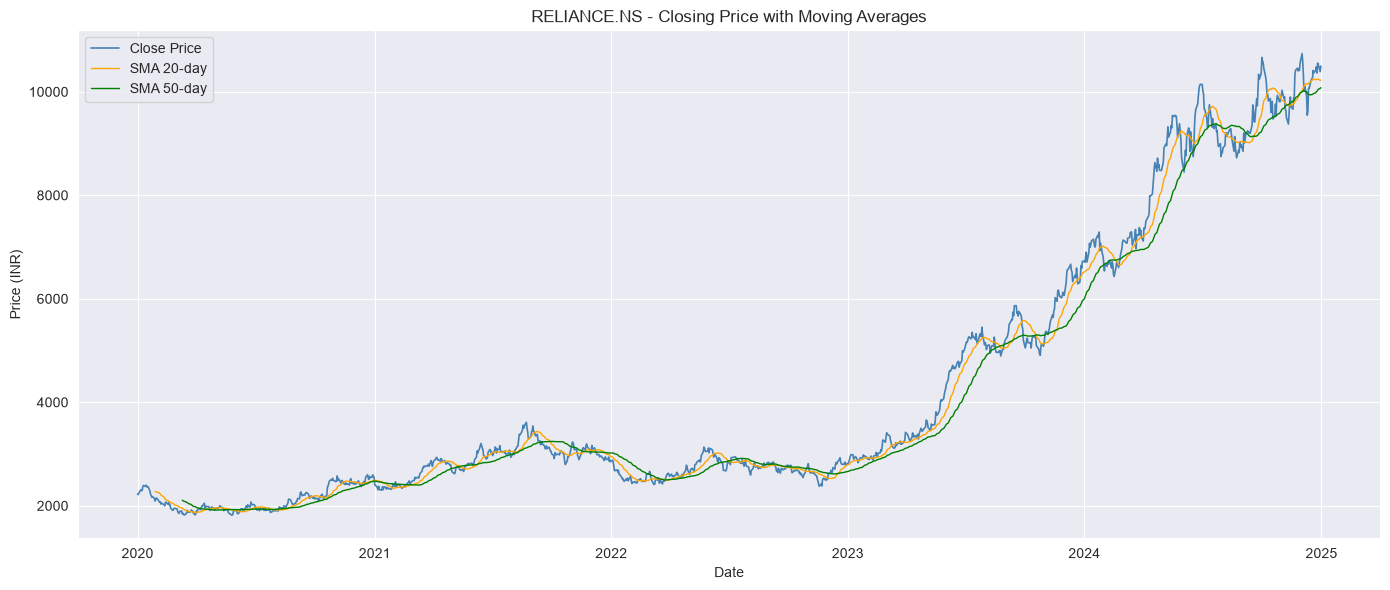

In [13]:
plt.figure(figsize=(14, 6))
plt.plot(df.index, df["Close"], label="Close Price", color="steelblue", linewidth=1.2)
plt.plot(df.index, df["SMA_20"], label="SMA 20-day", color="orange", linewidth=1)
plt.plot(df.index, df["SMA_50"], label="SMA 50-day", color="green", linewidth=1)
plt.title(f"{TICKER} - Closing Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price (INR)")
plt.legend()
plt.tight_layout()
plt.show()

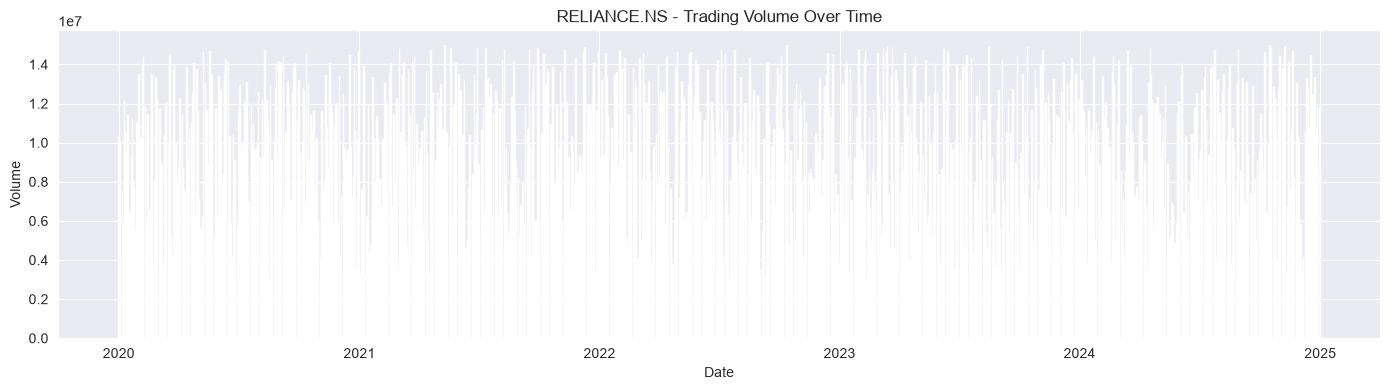

In [14]:
plt.figure(figsize=(14, 4))
plt.bar(df.index, df["Volume"], color="slategray", width=1.0)
plt.title(f"{TICKER} - Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.tight_layout()
plt.show()

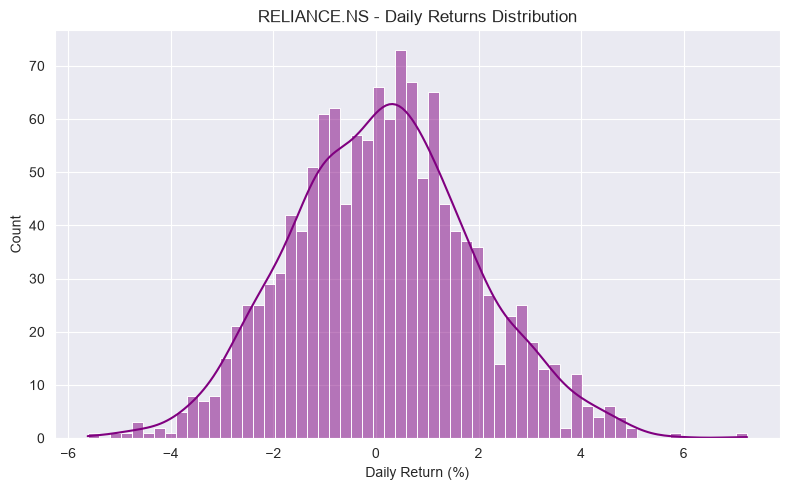

In [15]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Daily_Return"].dropna(), bins=60, kde=True, color="purple")
plt.title(f"{TICKER} - Daily Returns Distribution")
plt.xlabel("Daily Return (%)")
plt.tight_layout()
plt.show()

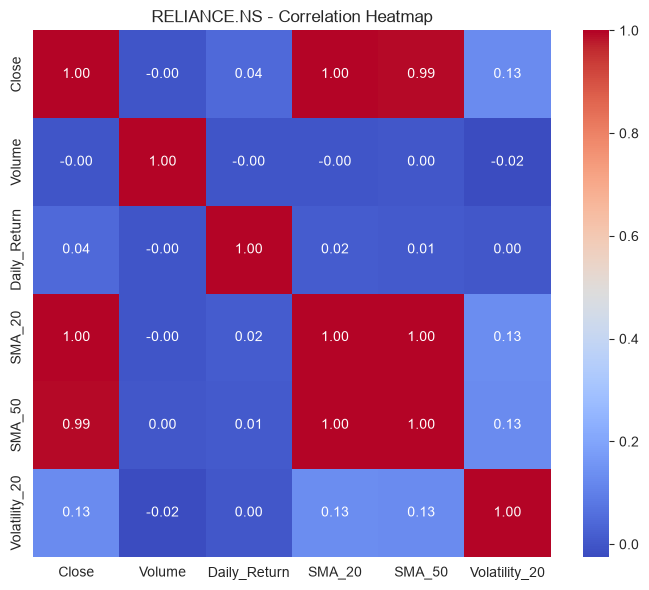

In [16]:
corr_cols = ["Close", "Volume", "Daily_Return", "SMA_20", "SMA_50", "Volatility_20"]
plt.figure(figsize=(7, 6))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title(f"{TICKER} - Correlation Heatmap")
plt.tight_layout()
plt.show()